# ML Assignment 2 — Income Classification (UCI Adult Dataset)

This notebook implements and evaluates 5 classification models (Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest) on the UCI Adult / Census Income dataset.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report
)

RANDOM_STATE = 42

## 1. Load Dataset

In [24]:
HERE = os.getcwd()
RAW_PATH = os.path.join(HERE, "..", "data", "raw", "adult_income_raw.csv")
df = pd.read_csv(RAW_PATH)
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Data Cleaning & Preprocessing

- Replace `?` with missing values
- Drop rows with a missing target
- Encode target: `<=50K` -> 0, `>50K` -> 1

In [25]:
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)
df = df.dropna(subset=['income'])
df['income'] = df['income'].astype(str).str.strip().str.replace('.', '', regex=False)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df = df.dropna(subset=['income'])
df['income'] = df['income'].astype(int)
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

### Quick EDA

In [26]:
df['income'].value_counts(normalize=True).rename({0: '<=50K', 1: '>50K'})

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

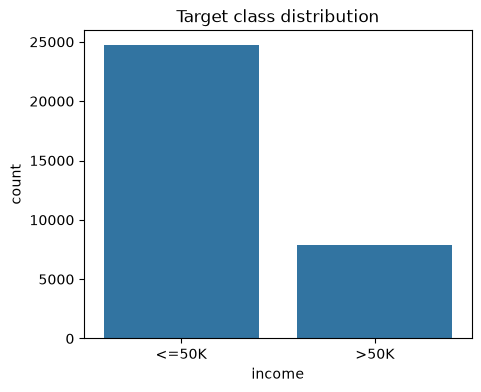

In [27]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x=df['income'].map({0: '<=50K', 1: '>50K'}), ax=ax)
ax.set_title('Target class distribution')
plt.show()

## 3. Feature / Target Split and Preprocessing Pipeline

In [28]:
NUMERIC_FEATURES = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
CATEGORICAL_FEATURES = ['workclass', 'education', 'marital.status', 'occupation',
                         'relationship', 'race', 'sex', 'native.country']
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURE_COLS]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((26048, 14), (6513, 14))

In [29]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
X_train_t.shape

(26048, 104)

## 4. Train 5 Classification Models

In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes': GaussianNB(),
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_t, y_train)
    fitted_models[name] = model
    print(f'Trained {name}')

Trained Logistic Regression
Trained Decision Tree
Trained kNN
Trained Naive Bayes
Trained Random Forest (Ensemble)


## 5. Evaluate: Accuracy, AUC, Precision, Recall, F1, MCC

In [31]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
    }

results = []
for name, model in fitted_models.items():
    metrics = evaluate(model, X_test_t, y_test)
    metrics['Model'] = name
    results.append(metrics)

metrics_df = pd.DataFrame(results)[['Model', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']]
metrics_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.853063,0.902445,0.739233,0.602041,0.663620,0.575799
1,Decision Tree,0.815292,0.752058,0.613284,0.630102,0.621579,0.499519
2,kNN,0.840626,0.886900,0.693149,0.606505,0.646939,0.546638
3,Naive Bayes,0.536619,0.733448,0.335973,0.947066,0.495992,0.323665
4,Random Forest (Ensemble),0.852602,0.901331,0.729261,0.616709,0.668279,0.577715


## 6. Confusion Matrices

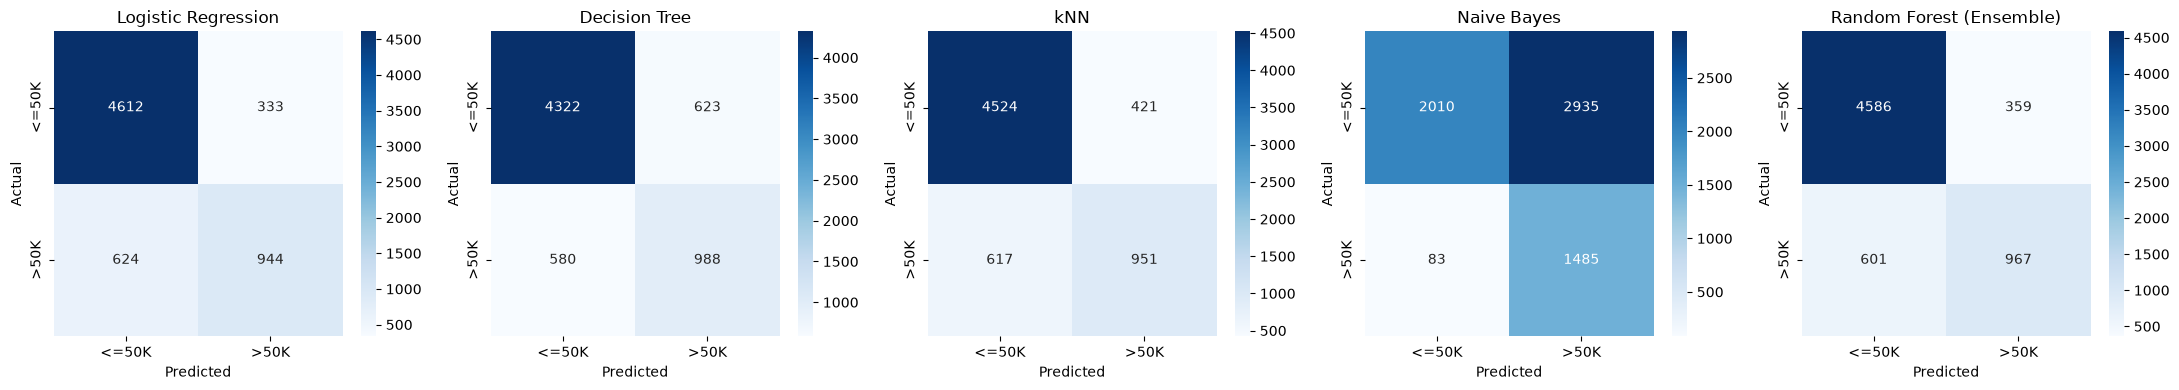

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_t))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Save Models, Preprocessor, and Metrics

(Also done by `model/train_models.py`, which this notebook mirrors.)

In [33]:
import joblib
import os

joblib.dump(preprocessor, '../model/preprocessor.pkl')
file_map = {
    'Logistic Regression': 'logistic_regression_model.pkl',
    'Decision Tree': 'decision_tree_model.pkl',
    'kNN': 'knn_model.pkl',
    'Naive Bayes': 'naive_bayes_model.pkl',
    'Random Forest (Ensemble)': 'random_forest_model.pkl',
}
for name, model in fitted_models.items():
    joblib.dump(model, f'../model/{file_map[name]}')

metrics_df.to_csv('../model/metrics.csv', index=False)
print('Saved all models, preprocessor, and metrics.')

Saved all models, preprocessor, and metrics.


## 8. Final Comparison Table

In [34]:
metrics_df.round(4)

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8531,0.9024,0.7392,0.6020,0.6636,0.5758
1,Decision Tree,0.8153,0.7521,0.6133,0.6301,0.6216,0.4995
2,kNN,0.8406,0.8869,0.6931,0.6065,0.6469,0.5466
3,Naive Bayes,0.5366,0.7334,0.3360,0.9471,0.4960,0.3237
4,Random Forest (Ensemble),0.8526,0.9013,0.7293,0.6167,0.6683,0.5777
